# CUDA Lab 01 — Applied Massive Parallelism
**Kystaubay Ayanat — Student ID 230103075**

Runtime → Change runtime type → **T4 GPU** → Save, then Runtime → **Run all**.

## Section 1 — Hardware telemetry

In [5]:
!nvidia-smi

Thu Oct  8 07:18:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P0             33W /   70W |     105MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
from numba import cuda
import os

device = cuda.get_current_device()

_raw_name = device.name
dev_name = _raw_name.decode('utf-8') if isinstance(_raw_name, bytes) else _raw_name

print(f"Device Name: {dev_name}")
print(f"Compute Capability: {device.compute_capability}")
print(f"Multiprocessor Count (SMs): {getattr(device, 'MULTIPROCESSOR_COUNT', 'N/A')}")
print(f"Max Threads Per Block: {device.MAX_THREADS_PER_BLOCK}")
print(f"Max Block Dimensions: {device.MAX_BLOCK_DIM_X}, {device.MAX_BLOCK_DIM_Y}, {device.MAX_BLOCK_DIM_Z}")
print(f"Warp Size: {device.WARP_SIZE}")

ctx = cuda.current_context()
free_b, total_b = ctx.get_memory_info()
print(f"Total VRAM: {total_b/1024**2:.0f} MiB | Free: {free_b/1024**2:.0f} MiB")

Device Name: Tesla T4
Compute Capability: ComputeCapability(major=7, minor=5)
Multiprocessor Count (SMs): 40
Max Threads Per Block: 1024
Max Block Dimensions: 1024, 1024, 64
Warp Size: 32
Total VRAM: 14913 MiB | Free: 14808 MiB


## Section 2 — Crossover experiment (CPU vs GPU)

In [7]:
import numpy as np
import time
from numba import cuda

# 1. CPU Reference Implementation (Pure Python loop)
def double_cpu_pure(arr):
    out = np.empty_like(arr)
    for i in range(len(arr)):
        out[i] = arr[i] * 2.0
    return out

# 2. GPU Kernel Implementation
@cuda.jit
def double_gpu_kernel(d_in, d_out):
    idx = cuda.grid(1)                      # unique 1D thread ID
    if idx < d_in.shape[0]:
        d_out[idx] = d_in[idx] * 2.0

In [8]:
def benchmark_run(N, student_id_seed=230103075):
    np.random.seed(student_id_seed % (2**32))
    h_in = np.random.rand(N).astype(np.float32)

    if N <= 1_000_000:
        t0 = time.perf_counter()
        _ = double_cpu_pure(h_in)
        cpu_time_ms = (time.perf_counter() - t0) * 1000.0
    else:
        cpu_time_ms = float('nan')

    threads_per_block = 256
    blocks_per_grid = (N + threads_per_block - 1) // threads_per_block

    d_warmup = cuda.to_device(np.ones(10, dtype=np.float32))
    double_gpu_kernel[1, 32](d_warmup, d_warmup)
    cuda.synchronize()

    # Roundtrip: PCIe H2D + kernel + PCIe D2H
    t0 = time.perf_counter()
    d_in = cuda.to_device(h_in)
    d_out = cuda.device_array_like(d_in)
    double_gpu_kernel[blocks_per_grid, threads_per_block](d_in, d_out)
    h_out = d_out.copy_to_host()
    cuda.synchronize()
    gpu_total_ms = (time.perf_counter() - t0) * 1000.0

    # Kernel only: data already in VRAM
    t0 = time.perf_counter()
    double_gpu_kernel[blocks_per_grid, threads_per_block](d_in, d_out)
    cuda.synchronize()
    gpu_compute_ms = (time.perf_counter() - t0) * 1000.0

    return cpu_time_ms, gpu_total_ms, gpu_compute_ms


SIZES = [100, 1_000, 10_000, 100_000, 1_000_000, 5_000_000, 10_000_000]
rows = []
print(f"{'N':>12} | {'CPU (ms)':>12} | {'GPU total (ms)':>15} | {'GPU kernel (ms)':>16} | Winner")
print("-" * 80)
for N in SIZES:
    cpu_ms, gpu_ms, ker_ms = benchmark_run(N)
    if np.isnan(cpu_ms):
        winner = "GPU (CPU skipped)"
        cpu_s = "skipped"
    else:
        winner = "GPU" if gpu_ms < cpu_ms else "CPU"
        cpu_s = f"{cpu_ms:.3f}"
    rows.append((N, cpu_ms, gpu_ms, ker_ms, winner))
    print(f"{N:>12,} | {cpu_s:>12} | {gpu_ms:>15.3f} | {ker_ms:>16.4f} | {winner}")

CROSSOVER_N = next((n for n, c, g, k, w in rows if not np.isnan(c) and g < c), None)
print(f"\nEmpirical crossover point N* = {CROSSOVER_N}")
print(f"At N = 100: GPU total {rows[0][2]:.3f} ms vs kernel only {rows[0][3]:.4f} ms "
      f"-> {100*(1 - rows[0][3]/rows[0][2]):.1f}% of the time was PCIe transfer + launch overhead")

           N |     CPU (ms) |  GPU total (ms) |  GPU kernel (ms) | Winner
--------------------------------------------------------------------------------


/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 40 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


         100 |        0.084 |           1.316 |           0.0909 | CPU
       1,000 |        0.252 |           0.567 |           0.0709 | CPU
      10,000 |        2.649 |           0.570 |           0.0774 | GPU
     100,000 |       28.545 |           0.754 |           0.0867 | GPU
   1,000,000 |      358.234 |           7.707 |           0.1795 | GPU
   5,000,000 |      skipped |          17.703 |           0.3120 | GPU (CPU skipped)
  10,000,000 |      skipped |          39.548 |           0.5285 | GPU (CPU skipped)

Empirical crossover point N* = 10000
At N = 100: GPU total 1.316 ms vs kernel only 0.0909 ms -> 93.1% of the time was PCIe transfer + launch overhead


## Section 3 — Thread geometry & boundary corruption

In [9]:
# DEFECTIVE KERNEL: notice the missing 'if idx < n' check
@cuda.jit
def defective_kernel(d_arr):
    idx = cuda.grid(1)
    d_arr[idx] = 999.0            # FORBIDDEN: no bounds check

N = 1000
h_arr = np.zeros(N, dtype=np.float32)
d_arr = cuda.to_device(h_arr)
threads_per_block = 256
blocks_per_grid = 4               # 4 x 256 = 1024 threads on a 1000-element array

print("Launching defective kernel with 1024 threads on 1000-element array...")
try:
    defective_kernel[blocks_per_grid, threads_per_block](d_arr)
    cuda.synchronize()
    print("Execution finished (or did it crash?). Checking host copy...")
    h_result = d_arr.copy_to_host()
    print(f"Elements processed: {len(h_result)}. Last element: {h_result[-1]}")
    print("No Python exception was raised - the 24 extra threads wrote past the buffer silently.")
except Exception as e:
    print(f"EXCEPTION RAISED: {type(e).__name__}")
    print(e)

Launching defective kernel with 1024 threads on 1000-element array...
Execution finished (or did it crash?). Checking host copy...
Elements processed: 1000. Last element: 999.0
No Python exception was raised - the 24 extra threads wrote past the buffer silently.


In [10]:
@cuda.jit
def inspect_threads_kernel(log_block, log_thread, log_global, log_active, N):
    t_idx = cuda.threadIdx.x
    b_idx = cuda.blockIdx.x
    g_idx = cuda.grid(1)
    if g_idx < log_block.shape[0]:
        log_block[g_idx] = b_idx
        log_thread[g_idx] = t_idx
        log_global[g_idx] = g_idx
        log_active[g_idx] = 1 if g_idx < N else 0

N = 37
threads_per_block = 8
blocks_per_grid = (N + threads_per_block - 1) // threads_per_block   # 5 blocks = 40 threads

log_b = cuda.device_array(blocks_per_grid * threads_per_block, dtype=np.int32)
log_t = cuda.device_array(blocks_per_grid * threads_per_block, dtype=np.int32)
log_g = cuda.device_array(blocks_per_grid * threads_per_block, dtype=np.int32)
log_a = cuda.device_array(blocks_per_grid * threads_per_block, dtype=np.int32)

inspect_threads_kernel[blocks_per_grid, threads_per_block](log_b, log_t, log_g, log_a, N)
cuda.synchronize()

hb, ht, hg, ha = log_b.copy_to_host(), log_t.copy_to_host(), log_g.copy_to_host(), log_a.copy_to_host()
print(f"{'Global ID':<10} | {'Block ID':<10} | {'Thread ID':<10} | {'Status':<10}")
print("-" * 50)
for i in range(32, 40):
    status = "ACTIVE" if ha[i] == 1 else "IDLE (GUARDED)"
    print(f"{hg[i]:<10} | {hb[i]:<10} | {ht[i]:<10} | {status:<10}")

total_threads = blocks_per_grid * threads_per_block
print(f"\nTotal blocks allocated: {blocks_per_grid}")
print(f"Total hardware threads launched: {total_threads}")
print(f"Active working threads: {int(ha.sum())}")
print(f"Idle guarded threads: {total_threads - int(ha.sum())}")

Global ID  | Block ID   | Thread ID  | Status    
--------------------------------------------------
32         | 4          | 0          | ACTIVE    
33         | 4          | 1          | ACTIVE    
34         | 4          | 2          | ACTIVE    
35         | 4          | 3          | ACTIVE    
36         | 4          | 4          | ACTIVE    
37         | 4          | 5          | IDLE (GUARDED)
38         | 4          | 6          | IDLE (GUARDED)
39         | 4          | 7          | IDLE (GUARDED)

Total blocks allocated: 5
Total hardware threads launched: 40
Active working threads: 37
Idle guarded threads: 3


/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 5 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


## Section 4 — Race condition vs atomic reduction

In [11]:
@cuda.jit
def naive_sum_kernel(d_arr, d_total):
    idx = cuda.grid(1)
    if idx < d_arr.shape[0]:
        d_total[0] += d_arr[idx]          # DATA RACE

@cuda.jit
def atomic_sum_kernel(d_arr, d_total):
    idx = cuda.grid(1)
    if idx < d_arr.shape[0]:
        cuda.atomic.add(d_total, 0, d_arr[idx])   # hardware atomic

M = 50_000
arr = np.ones(M, dtype=np.float32)
d_arr = cuda.to_device(arr)
tpb = 256
bpg = (M + tpb - 1) // tpb

# warm-up compile
d_tmp = cuda.to_device(np.zeros(1, dtype=np.float32))
naive_sum_kernel[bpg, tpb](d_arr, d_tmp)
atomic_sum_kernel[bpg, tpb](d_arr, d_tmp)
cuda.synchronize()

print(f"{'Trial':<8} | {'Target':>10} | {'Naive output':>14} | {'Lost updates':>14}")
print("-" * 56)
naive_vals = []
for trial in range(1, 6):
    d_total = cuda.to_device(np.zeros(1, dtype=np.float32))
    naive_sum_kernel[bpg, tpb](d_arr, d_total)
    cuda.synchronize()
    val = float(d_total.copy_to_host()[0])
    naive_vals.append(val)
    print(f"{trial:<8} | {50000.0:>10.1f} | {val:>14.1f} | {50000.0 - val:>14.1f}")

d_total = cuda.to_device(np.zeros(1, dtype=np.float32))
atomic_sum_kernel[bpg, tpb](d_arr, d_total)
cuda.synchronize()
atomic_val = float(d_total.copy_to_host()[0])
print(f"\nAtomic sum output: {atomic_val} | exactly 50000.0? {atomic_val == 50000.0}")

def timed(kernel, reps=20):
    d_t = cuda.to_device(np.zeros(1, dtype=np.float32))
    kernel[bpg, tpb](d_arr, d_t); cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(reps):
        kernel[bpg, tpb](d_arr, d_t)
    cuda.synchronize()
    return (time.perf_counter() - t0) / reps * 1000.0

t_naive = timed(naive_sum_kernel)
t_atomic = timed(atomic_sum_kernel)
print(f"Naive kernel time : {t_naive:.4f} ms")
print(f"Atomic kernel time: {t_atomic:.4f} ms")
print(f"Atomic / naive    : {t_atomic / t_naive:.2f}x")

Trial    |     Target |   Naive output |   Lost updates
--------------------------------------------------------
1        |    50000.0 |            2.0 |        49998.0
2        |    50000.0 |            2.0 |        49998.0
3        |    50000.0 |            2.0 |        49998.0
4        |    50000.0 |            2.0 |        49998.0
5        |    50000.0 |            2.0 |        49998.0

Atomic sum output: 50000.0 | exactly 50000.0? True
Naive kernel time : 0.0354 ms
Atomic kernel time: 0.1876 ms
Atomic / naive    : 5.31x


## Section 5 — 2D grid: radial vignette

Generated 2D matrix shape: (1024, 1024). Center value: 1.000
Blocks in X: 64 | Blocks in Y: 64 | Total blocks: 4096
Threads per block: 16x16 = 256
Pixel value at center (512, 512): 1.000000
Pixel value at outer corner (0, 0): 0.000000


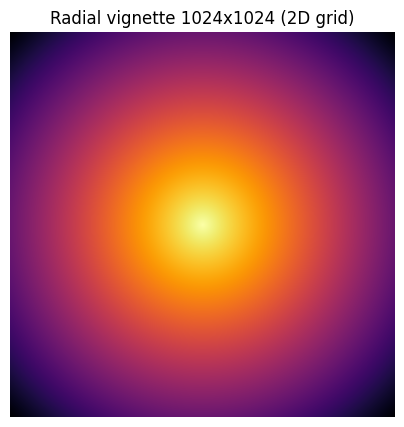

In [12]:
import math

@cuda.jit
def radial_vignette_2d(d_canvas, width, height, center_x, center_y):
    x, y = cuda.grid(2)
    if x < width and y < height:
        dx = float(x - center_x)
        dy = float(y - center_y)
        dist = math.sqrt(dx * dx + dy * dy)
        max_dist = math.sqrt(float(center_x**2 + center_y**2))
        intensity = 1.0 - (dist / max_dist)
        if intensity < 0.0:
            intensity = 0.0
        d_canvas[y, x] = intensity

WIDTH, HEIGHT = 1024, 1024
canvas = np.zeros((HEIGHT, WIDTH), dtype=np.float32)
d_canvas = cuda.to_device(canvas)

threads_2d = (16, 16)
blocks_2d = ((WIDTH + threads_2d[0] - 1) // threads_2d[0],
             (HEIGHT + threads_2d[1] - 1) // threads_2d[1])

radial_vignette_2d[blocks_2d, threads_2d](d_canvas, WIDTH, HEIGHT, WIDTH // 2, HEIGHT // 2)
cuda.synchronize()
result_canvas = d_canvas.copy_to_host()

print(f"Generated 2D matrix shape: {result_canvas.shape}. Center value: {result_canvas[512, 512]:.3f}")
print(f"Blocks in X: {blocks_2d[0]} | Blocks in Y: {blocks_2d[1]} | Total blocks: {blocks_2d[0]*blocks_2d[1]}")
print(f"Threads per block: {threads_2d[0]}x{threads_2d[1]} = {threads_2d[0]*threads_2d[1]}")
print(f"Pixel value at center (512, 512): {result_canvas[512, 512]:.6f}")
print(f"Pixel value at outer corner (0, 0): {result_canvas[0, 0]:.6f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.imshow(result_canvas, cmap='inferno')
plt.title('Radial vignette 1024x1024 (2D grid)')
plt.axis('off')
plt.savefig('vignette_output.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6 — Verification checksum

In [13]:
import hashlib

def generate_lab_checksum(student_id_str, d_canvas, exp_table_crossover):
    h = hashlib.sha256()
    h.update(student_id_str.strip().encode('utf-8'))
    _n = cuda.get_current_device().name
    h.update(_n if isinstance(_n, bytes) else _n.encode('utf-8'))
    h.update(d_canvas.copy_to_host()[:10, :10].tobytes())
    h.update(str(exp_table_crossover).encode('utf-8'))
    digest = h.hexdigest()[:16].upper()
    print("=" * 60)
    print(f"OFFICIAL VERIFICATION CHECKSUM TOKEN: {digest}")
    print("=" * 60)
    return digest

STUDENT_ID = "230103075"
print(f"Using empirical crossover N* = {CROSSOVER_N}")
token = generate_lab_checksum(STUDENT_ID, d_canvas, CROSSOVER_N)

Using empirical crossover N* = 10000
OFFICIAL VERIFICATION CHECKSUM TOKEN: 568F4EA22E3218E5
